impoting libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importing dataset

In [2]:
df = pd.read_csv('Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


Split into X and Y

In [18]:
X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values

Reshape Y into 2D

In [19]:
y = y.reshape(-1, 1)

feature scaling

In [20]:
from sklearn.preprocessing import StandardScaler

scale_X = StandardScaler()
scale_y = StandardScaler()

X = scale_X.fit_transform(X)
y = scale_y.fit_transform(y)

training the SVR model on the whole dataset

In [21]:
from sklearn.svm import SVR

model = SVR(kernel='rbf')
model.fit(X, y.ravel())   

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


Predict salary at Level 6.5

In [22]:
level = 6.5
level_scaled = scale_X.transform([[level]])
pred_scaled = model.predict(level_scaled)
pred = scale_y.inverse_transform(pred_scaled.reshape(-1, 1))

print(pred)

[[170370.0204065]]


Visualize the SVR fit

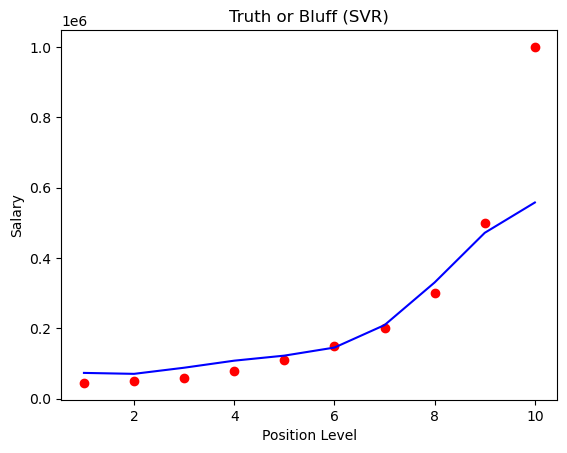

In [23]:
plt.scatter(scale_X.inverse_transform(X), scale_y.inverse_transform(y), color='red')
plt.plot(scale_X.inverse_transform(X), scale_y.inverse_transform(model.predict(X).reshape(-1,1)), color='blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()